In [1]:
"""
Compute a monthly climatology for dissolved oxygen from the BATS CTD dataset.

This module reads the Bermuda Atlantic Time‑series Study (BATS) CTD data
(version 11) and generates a seasonal climatology of dissolved oxygen on
a fixed depth grid.  Each sample in the input CSV contains multiple
variables, including the deployment time, collection depth, and
dissolved oxygen concentration.  The script performs the following
processing steps:

* Parse the deployment timestamp (``ISO_DateTime_UTC_deployed``) or
  fallback to other ISO date fields to determine the sample month.
* Convert the ``Depth`` column (meters) to floats, snap to a
  user‑configurable depth grid and discard samples that fall outside a
  tolerance window.
* Convert the ``Oxygen`` column (µmol kg⁻¹) to numeric and drop
  missing values.
* Group the data by month and depth and compute the mean oxygen
  concentration for each combination across all years.

The output is an ``xarray.Dataset`` with dimensions ``month`` and
``depth`` containing the climatological oxygen concentration.  You can
override the depth grid or tolerance by passing parameters to
``build_ctd_climatology``.

"""

from __future__ import annotations

import io
import warnings
from typing import Optional

import numpy as np
import pandas as pd
import xarray as xr
import requests

__all__ = [
    'STANDARD_DEPTHS',
    'DEPTH_TOLERANCE',
    'download_ctd_data',
    'preprocess_ctd',
    'compute_monthly_climatology',
    'build_ctd_climatology',
]

import os
wrkdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(wrkdir)
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations'

In [14]:

# Define a standard depth grid (in metres) appropriate for the BATS pigment
# dataset.  BATS pigment casts usually sample 12 depths between 0 and
# roughly 250 m.  Here we adopt a 10 m resolution up to 300 m, which is
# flexible enough to accommodate occasional deeper samples.  Adjust this
# array if you wish to alter the vertical resolution or range.
STANDARD_DEPTHS: np.ndarray = np.arange(0, 301, 20)

# Maximum difference (in metres) allowed when matching observed depths to
# ``STANDARD_DEPTHS``.  If the absolute difference between an observed
# depth and the nearest standard depth exceeds this value, the sample is
# discarded.  Increase this tolerance to retain more data, or decrease it
# to enforce stricter matching.
DEPTH_TOLERANCE: float = 10.0

# Names of the CTD variables to include in the climatology.  Keys are
# column names in the raw file; values are the variable names used in
# the output dataset.  You can modify this mapping to include
# additional variables present in the CTD dataset (e.g., 'Flu' for
# fluorescence or 'BAC' for beam attenuation).  The script will
# silently skip any variables not found in the input file.
VARIABLES = {
    'Oxygen': 'oxygen',
    'Temperature': 'temperature',
    'Salinity': 'salinity',
    'PAR': 'par',
}


### DOWNLOAD

In [3]:
def download_ctd_data(url_or_path: str) -> pd.DataFrame:
    """Download or read the CTD dataset into a DataFrame.

    Parameters
    ----------
    url_or_path : str
        HTTP(S) URL or local file path pointing to the CTD CSV.

    Returns
    -------
    pandas.DataFrame
        Raw CTD data.  Returns an empty DataFrame on failure.
    """
    try:
        if url_or_path.startswith(('http://', 'https://')):
            resp = requests.get(url_or_path, timeout=60)
            resp.raise_for_status()
            content = resp.content
            return pd.read_csv(io.BytesIO(content), dtype=str)
        else:
            return pd.read_csv(url_or_path, dtype=str)
    except Exception as exc:
        warnings.warn(f"Failed to load CTD data from {url_or_path}: {exc}")
        return pd.DataFrame()

### PROCESS

In [15]:
def preprocess_ctd(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess the raw CTD DataFrame for climatology.

    This function standardises the CTD measurements by performing the
    following operations:

    * Identify a valid timestamp column (priority: ``ISO_DateTime_UTC_deployed``,
      ``ISO_DateTime_UTC``, then ``Date``) and parse it to extract
      calendar months.
    * Convert the ``Depth`` column to numeric values and assign each
      sample to the nearest depth in ``STANDARD_DEPTHS`` provided the
      difference is within ``DEPTH_TOLERANCE``.
    * Convert the variables listed in the global ``VARIABLES`` mapping
      (e.g., oxygen, temperature, salinity, PAR) to numeric values.  If
      none of the requested variables are present, the function
      returns an empty DataFrame.
    * Remove rows where all selected variables are missing.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw CTD dataset loaded from a CSV file.

    Returns
    -------
    pandas.DataFrame
        Tidy DataFrame with columns ``month``, ``depth`` and one
        column per selected CTD variable.  Each variable is renamed
        according to the ``VARIABLES`` mapping.  Returns an empty
        DataFrame if the preprocessing fails or no requested variables
        are found.
    """
    if df.empty:
        return df

    # Determine which date column to use
    date_candidates = [
        'ISO_DateTime_UTC_deployed',
        'ISO_DateTime_UTC',
        'Date',
    ]
    date_col = None
    for col in date_candidates:
        if col in df.columns:
            date_col = col
            break
    if date_col is None:
        warnings.warn("No valid date column found in CTD data.")
        return pd.DataFrame()
    df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
    df.dropna(subset=['datetime'], inplace=True)
    df['month'] = df['datetime'].dt.month

    # Depth
    if 'Depth' not in df.columns:
        warnings.warn("No 'Depth' column found in CTD data.")
        return pd.DataFrame()
    df['depth_orig'] = pd.to_numeric(df['Depth'], errors='coerce')
    df.dropna(subset=['depth_orig'], inplace=True)
    # Snap to standard depths
    idxs = np.abs(df['depth_orig'].values[:, None] - STANDARD_DEPTHS[None, :]).argmin(axis=1)
    snapped = STANDARD_DEPTHS[idxs]
    within = np.abs(df['depth_orig'] - snapped) <= DEPTH_TOLERANCE
    df = df.loc[within].copy()
    df['depth'] = snapped[within.values]

    # Convert selected CTD variables to numeric.  Missing variables are ignored.
    # At least one must exist; otherwise there is nothing to climatologize.
    present_vars = []
    for raw_name, out_name in VARIABLES.items():
        if raw_name in df.columns:
            df[out_name] = pd.to_numeric(df[raw_name], errors='coerce')
            present_vars.append(out_name)
    if not present_vars:
        warnings.warn("None of the requested variables were found in the CTD data.")
        return pd.DataFrame()
    # Drop rows where all selected variables are NaN
    df.dropna(subset=present_vars, how='all', inplace=True)
    cols = ['month', 'depth'] + present_vars
    return df[cols]



### CLIMATOLOGY

In [16]:
def compute_monthly_climatology(df: pd.DataFrame) -> xr.Dataset:
    """Compute monthly climatology for multiple CTD variables.

    Parameters
    ----------
    df : pandas.DataFrame
        Tidy DataFrame with ``month`` and ``depth`` columns plus one or
        more CTD variables (e.g., ``oxygen``, ``temperature``, ``salinity``, ``par``).

    Returns
    -------
    xarray.Dataset
        Dataset with dimensions ``month`` and ``depth`` containing the
        mean of each CTD variable across all years.  Only variables
        present in ``df`` are included.
    """
    months = np.arange(1, 13)
    depths = STANDARD_DEPTHS.copy()
    data_vars = {}
    for var in df.columns:
        if var in ('month', 'depth'):
            continue
        pivot = df.pivot_table(index='month', columns='depth', values=var, aggfunc='mean')
        pivot = pivot.reindex(index=months, columns=depths)
        data_vars[var] = (('month', 'depth'), pivot.values.astype(float))
    units = {
        'oxygen': 'µmol kg^-1',
        'temperature': '°C',
        'salinity': 'PSU',
        'par': 'µE m^-2 s^-1',
    }
    ds = xr.Dataset(
        data_vars=data_vars,
        coords={'month': months, 'depth': depths},
        attrs={'description': 'Monthly climatology of BATS CTD variables on a fixed depth grid'}
    )
    # Attach units as attribute for each variable if known
    for var, da in ds.data_vars.items():
        if var in units:
            da.attrs['units'] = units[var]
    return ds


### BUILD

In [17]:
def build_ctd_climatology(url_or_path: str, depth_grid: Optional[np.ndarray] = None) -> xr.Dataset:
    """Download, preprocess and compute monthly climatology for CTD oxygen.

    Parameters
    ----------
    url_or_path : str
        URL or local path to the CTD CSV file.
    depth_grid : array-like of float, optional
        Custom depth grid.  If provided, this overrides the default
        ``STANDARD_DEPTHS`` for depth assignment and output coordinates.

    Returns
    -------
    xarray.Dataset
        Dataset containing the monthly climatology of oxygen.  Raises
        ``RuntimeError`` if no valid data remain after preprocessing.
    """
    global STANDARD_DEPTHS
    if depth_grid is not None:
        STANDARD_DEPTHS = np.asarray(depth_grid, dtype=float)
    raw = download_ctd_data(url_or_path)
    tidy = preprocess_ctd(raw)
    if tidy.empty:
        raise RuntimeError("No valid oxygen data after preprocessing.")
    return compute_monthly_climatology(tidy)



### call

In [ ]:
%%time

link = "https://datadocs.bco-dmo.org/dataset/3918/file/l81k3ABfox7nlJ/3918_v11_bats_ctd.csv"
ds = build_ctd_climatology(link)
print(ds)


In [22]:
print(ds)

<xarray.Dataset> Size: 6kB
Dimensions:      (month: 12, depth: 16)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * depth        (depth) int64 128B 0 20 40 60 80 100 ... 220 240 260 280 300
Data variables:
    oxygen       (month, depth) float64 2kB 218.5 218.7 218.6 ... 201.9 201.6
    temperature  (month, depth) float64 2kB 20.92 20.91 20.89 ... 18.51 18.41
    salinity     (month, depth) float64 2kB 36.69 36.69 36.69 ... 36.58 36.57
    par          (month, depth) float64 2kB 161.6 60.3 ... 0.000804 0.0008273
Attributes:
    description:  Monthly climatology of BATS CTD variables on a fixed depth ...


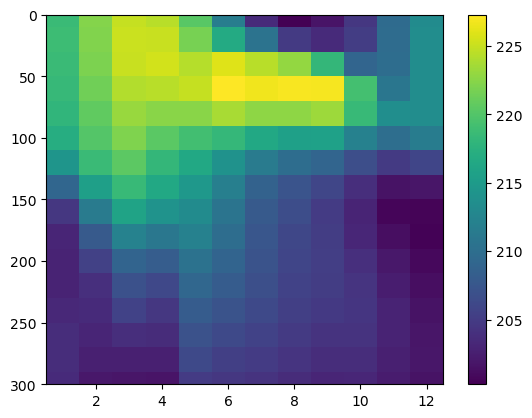

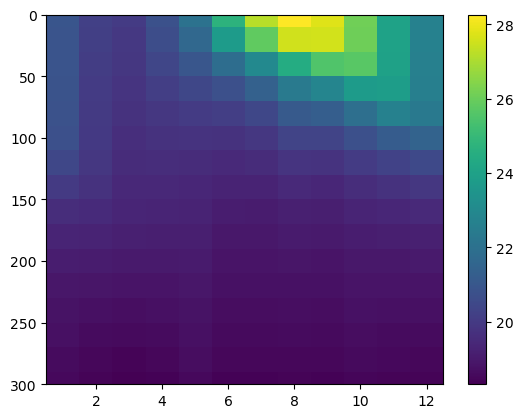

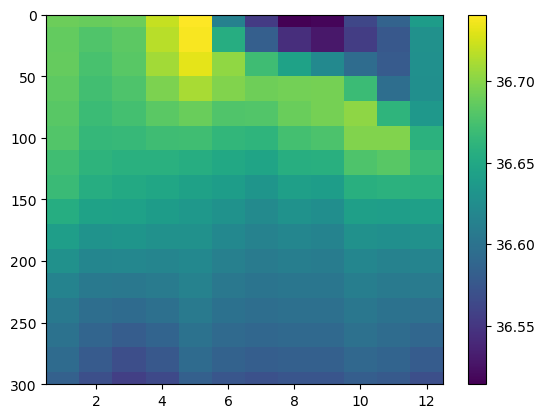

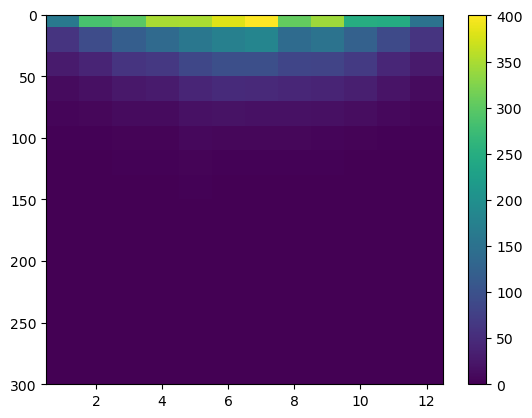

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['oxygen'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['temperature'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['salinity'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['par'].T)
plt.ylim(300,0)
plt.colorbar()




### SAVE

In [24]:
%%time
    
ds.to_netcdf('./bats_CTD_O2_PAR_monthly_climatology.nc')

CPU times: user 256 ms, sys: 151 ms, total: 407 ms
Wall time: 1.53 s
